# mmHawkeye LSTM training pipeline

This notebook trains a paper-inspired binary UAV classifier from the repository's native Mini4 PMM JSONL output. It is an adaptation, not an exact reproduction: the paper does not publish its exact tensor dimensions, while this pipeline uses 3.6 seconds at 10 Hz (36 × 64).

Place complete captures under dataset/uav/ and dataset/other/. Each JSONL file is one labelled capture. Tracking and identification use non-demeaned Doppler spectra; tracking clutter is removed from folded R-PMM scores by calibrated projection subtraction. This notebook applies the paper's identification center-bin DC-removal operation and then aligns each spectrum's body peak to the center.

**Run cells in order.** The repository version intentionally contains no executed cells, trained weights, metrics, or generated artifacts.

In [19]:
from google.colab import drive

drive.mount("/content/drive")
%cd /content/drive/MyDrive/UREX/Radar-UREx

%pip install -q onnx onnxscript


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/UREX/Radar-UREx


In [20]:
from __future__ import annotations

import copy
import hashlib
import json
import os
import platform
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import onnx
import sklearn
import torch
from onnx.reference import ReferenceEvaluator
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
SEGMENT_FRAMES = 36
DOPPLER_BINS = 64
CENTER_BIN = DOPPLER_BINS // 2
CENTER_TOLERANCE_BINS = 1
TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
TEST_FRACTION = 0.15
BATCH_SIZE = 10
LEARNING_RATE = 5e-5
EPOCHS = 100
HIDDEN_SIZE = 128
NUM_LSTM_LAYERS = 2
ONNX_OPSET = 18
LABEL_TO_INDEX = {"other": 0, "uav": 1}
INDEX_TO_LABEL = {value: key for key, value in LABEL_TO_INDEX.items()}

REPO = Path.cwd().resolve()
if not (REPO / "rawdatacapture" / "profile-mini4-20m.cfg").is_file():
    raise RuntimeError("Run this notebook from the Radar-UREx repository root")
DATASET_ROOT = Path(os.environ.get("RADAR_UREX_DATASET", REPO / "dataset")).resolve()
OUTPUT_DIR = Path(
    os.environ.get(
        "RADAR_UREX_TRAINING_OUTPUT",
        REPO / "training_output" / "mmhawkeye_lstm",
    )
).resolve()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()
print({
    "dataset_root": str(DATASET_ROOT),
    "output_dir": str(OUTPUT_DIR),
    "device": str(DEVICE),
    "seed": SEED,
    "input_shape": [SEGMENT_FRAMES, DOPPLER_BINS],
})


{'dataset_root': '/content/drive/MyDrive/UREX/Radar-UREx/dataset', 'output_dir': '/content/drive/MyDrive/UREX/Radar-UREx/training_output/mmhawkeye_lstm', 'device': 'cuda', 'seed': 42, 'input_shape': [36, 64]}


## 1. Capture validation and segment extraction

Only current mini4-pmm-jsonl captures are accepted. All captures must share one profile fingerprint, feature fingerprint, feature version, and detection threshold. Empty or partial rolling histories are valid capture records but are not training examples.

In [21]:
@dataclass(frozen=True)
class Capture:
    path: Path
    relative_path: str
    label_name: str
    label: int
    sha256: str
    metadata: dict[str, Any]
    updates: tuple[dict[str, Any], ...]

@dataclass(frozen=True)
class Segment:
    segment_id: str
    capture_path: str
    capture_sha256: str
    end_frame_index: int
    label_name: str
    label: int
    values: np.ndarray
    maximum_pmm_score: float
    threshold: float

def _sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as source:
        for chunk in iter(lambda: source.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def _finite_float(value: Any, field: str, path: Path, line_number: int) -> float:
    try:
        result = float(value)
    except (TypeError, ValueError) as exc:
        raise ValueError(f"{path}:{line_number}: {field} must be numeric") from exc
    if not np.isfinite(result):
        raise ValueError(f"{path}:{line_number}: {field} must be finite")
    return result

def read_capture(path: Path, dataset_root: Path = DATASET_ROOT) -> Capture:
    path = path.resolve()
    try:
        relative = path.relative_to(dataset_root.resolve())
    except ValueError as exc:
        raise ValueError(f"Capture is outside dataset root: {path}") from exc
    if not relative.parts or relative.parts[0] not in LABEL_TO_INDEX:
        raise ValueError(f"Capture must be under dataset/uav or dataset/other: {path}")
    label_name = relative.parts[0]
    metadata = None
    updates: list[dict[str, Any]] = []
    previous_frame_index = -1
    with path.open("r", encoding="utf-8") as source:
        for line_number, raw_line in enumerate(source, start=1):
            if not raw_line.strip():
                continue
            try:
                record = json.loads(raw_line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"{path}:{line_number}: invalid JSON") from exc
            if not isinstance(record, dict):
                raise ValueError(f"{path}:{line_number}: record must be an object")
            if metadata is None:
                if record.get("record_type") != "metadata":
                    raise ValueError(f"{path}:{line_number}: first record must be metadata")
                metadata = record
                continue
            if record.get("record_type") != "update":
                raise ValueError(f"{path}:{line_number}: unexpected record_type")
            frame_index = int(record.get("processed_frame_index", -1))
            if frame_index <= previous_frame_index:
                raise ValueError(f"{path}:{line_number}: frame indices must increase")
            previous_frame_index = frame_index
            tracking = record.get("pmm_tracking")
            if not isinstance(tracking, dict):
                raise ValueError(f"{path}:{line_number}: missing pmm_tracking")
            if tracking.get("pmm_score") is not None:
                _finite_float(tracking["pmm_score"], "pmm_score", path, line_number)
            _finite_float(tracking.get("threshold"), "threshold", path, line_number)
            history_data = record.get("doppler_time_db")
            if history_data == []:
                history = np.empty((0, DOPPLER_BINS), dtype=np.float32)
            else:
                history = np.asarray(history_data, dtype=np.float32)
                if history.ndim != 2 or history.shape[1] != DOPPLER_BINS:
                    raise ValueError(
                        f"{path}:{line_number}: doppler_time_db must have shape [T, {DOPPLER_BINS}]"
                    )
                if history.shape[0] > SEGMENT_FRAMES:
                    raise ValueError(f"{path}:{line_number}: Doppler history is too long")
                if not np.isfinite(history).all():
                    raise ValueError(f"{path}:{line_number}: Doppler history contains non-finite values")
            record["_history"] = history
            updates.append(record)
    if metadata is None:
        raise ValueError(f"{path}: capture is empty")
    if metadata.get("format") != "mini4-pmm-jsonl" or metadata.get("version") != 1:
        raise ValueError(f"{path}: unsupported capture format or version")
    pmm_metadata = metadata.get("pmm_tracking")
    if not isinstance(pmm_metadata, dict):
        raise ValueError(f"{path}: metadata is missing pmm_tracking")
    required = ("feature_version", "feature_fingerprint", "profile_fingerprint")
    missing = [name for name in required if not pmm_metadata.get(name)]
    if missing:
        raise ValueError(f"{path}: metadata is missing {missing}")
    if int(pmm_metadata.get("doppler_fft_size", -1)) != DOPPLER_BINS:
        raise ValueError(f"{path}: expected {DOPPLER_BINS} Doppler bins")
    config = pmm_metadata.get("config")
    if not isinstance(config, dict) or "adaptive_threshold_sigma" not in config or "adaptive_threshold_minimum" not in config:
        raise ValueError(f"{path}: metadata is missing adaptive threshold settings")
    _finite_float(config["adaptive_threshold_sigma"], "adaptive_threshold_sigma", path, 1)
    _finite_float(config["adaptive_threshold_minimum"], "adaptive_threshold_minimum", path, 1)
    if config.get("detection_threshold") is not None:
        _finite_float(config["detection_threshold"], "detection_threshold", path, 1)
    return Capture(
        path=path,
        relative_path=relative.as_posix(),
        label_name=label_name,
        label=LABEL_TO_INDEX[label_name],
        sha256=_sha256_file(path),
        metadata=metadata,
        updates=tuple(updates),
    )


In [22]:
def align_doppler_time(history_db: np.ndarray) -> np.ndarray:
    """Apply paper-style DC removal, body-peak alignment, and compression."""
    history_db = np.asarray(history_db, dtype=np.float32)
    if history_db.shape != (SEGMENT_FRAMES, DOPPLER_BINS):
        raise ValueError(f"Expected [{SEGMENT_FRAMES}, {DOPPLER_BINS}], got {history_db.shape}")
    if not np.isfinite(history_db).all():
        raise ValueError("Doppler segment contains non-finite values")
    amplitude = np.power(10.0, history_db / 20.0, dtype=np.float32)
    body_peak_bins = np.argmax(amplitude, axis=1)
    away_from_dc = np.abs(body_peak_bins - CENTER_BIN) > CENTER_TOLERANCE_BINS
    dc_removed = amplitude.copy()
    if np.any(away_from_dc):
        dc_noise = float(np.mean(amplitude[away_from_dc, CENTER_BIN]))
        dc_removed[:, CENTER_BIN] = np.maximum(
            dc_removed[:, CENTER_BIN] - dc_noise,
            0.0,
        )
    coordinates = np.arange(DOPPLER_BINS, dtype=np.float32)
    aligned = np.empty_like(amplitude)
    for time_index, spectrum in enumerate(dc_removed):
        body_peak_bin = int(body_peak_bins[time_index])
        if abs(body_peak_bin - CENTER_BIN) <= CENTER_TOLERANCE_BINS:
            aligned[time_index] = spectrum
            continue
        shift = CENTER_BIN - body_peak_bin
        aligned[time_index] = np.interp(
            coordinates - shift,
            coordinates,
            spectrum,
            left=0.0,
            right=0.0,
        ).astype(np.float32)
    return np.log1p(aligned).astype(np.float32)

def extract_segments(capture: Capture) -> list[Segment]:
    score_and_threshold_by_frame = {
        int(update["processed_frame_index"]): (
            update["pmm_tracking"].get("pmm_score"),
            float(update["pmm_tracking"]["threshold"]),
        )
        for update in capture.updates
    }
    segments: list[Segment] = []
    last_kept_end: int | None = None
    for update in capture.updates:
        history = update["_history"]
        if history.shape != (SEGMENT_FRAMES, DOPPLER_BINS):
            continue
        end_frame = int(update["processed_frame_index"])
        if last_kept_end is not None and end_frame - last_kept_end < SEGMENT_FRAMES:
            continue
        window_indices = range(end_frame - SEGMENT_FRAMES + 1, end_frame + 1)
        window_values = [score_and_threshold_by_frame.get(index) for index in window_indices]
        if any(value is None or value[0] is None for value in window_values):
            continue
        gate_score, threshold = max(
            window_values,
            key=lambda value: float(value[0]) - float(value[1]),
        )
        maximum_score = float(max(float(value[0]) for value in window_values))
        if float(gate_score) < float(threshold):
            continue
        segment_id = hashlib.sha256(
            f"{capture.relative_path}:{capture.sha256}:{end_frame}".encode("utf-8")
        ).hexdigest()
        segments.append(Segment(
            segment_id=segment_id,
            capture_path=capture.relative_path,
            capture_sha256=capture.sha256,
            end_frame_index=end_frame,
            label_name=capture.label_name,
            label=capture.label,
            values=align_doppler_time(history),
            maximum_pmm_score=maximum_score,
            threshold=threshold,
        ))
        last_kept_end = end_frame
    return segments

def load_dataset(dataset_root: Path = DATASET_ROOT) -> tuple[list[Capture], list[Segment], dict[str, Any]]:
    paths = sorted(
        path
        for label_name in LABEL_TO_INDEX
        for path in (dataset_root / label_name).rglob("*.jsonl")
    )
    if not paths:
        raise FileNotFoundError(
            f"No captures found. Add JSONL files under {dataset_root / 'uav'} and {dataset_root / 'other'}"
        )
    captures = [read_capture(path, dataset_root) for path in paths]
    contracts = {
        "profile_fingerprint": {c.metadata["pmm_tracking"]["profile_fingerprint"] for c in captures},
        "feature_fingerprint": {c.metadata["pmm_tracking"]["feature_fingerprint"] for c in captures},
        "feature_version": {c.metadata["pmm_tracking"]["feature_version"] for c in captures},
        "threshold_config": {(c.metadata["pmm_tracking"]["config"].get("detection_threshold"), float(c.metadata["pmm_tracking"]["config"]["adaptive_threshold_sigma"]), float(c.metadata["pmm_tracking"]["config"]["adaptive_threshold_minimum"])) for c in captures},
    }
    incompatible = {name: values for name, values in contracts.items() if len(values) != 1}
    if incompatible:
        raise ValueError(f"Dataset mixes incompatible capture contracts: {incompatible}")
    segments = [segment for capture in captures for segment in extract_segments(capture)]
    if not segments:
        raise ValueError("No complete 3.6-second segments passed the PMM quality gate")
    observed_labels = {segment.label_name for segment in segments}
    if observed_labels != set(LABEL_TO_INDEX):
        raise ValueError(f"Both classes require usable segments; observed {sorted(observed_labels)}")
    audit = {
        "capture_count": len(captures),
        "segment_count_before_balance": len(segments),
        "capture_files": {capture.relative_path: capture.sha256 for capture in captures},
        **{name: next(iter(values)) for name, values in contracts.items()},
    }
    return captures, segments, audit


## 2. Balance, split, and normalize

The majority class is deterministically undersampled. Each class is independently shuffled and divided into approximately 70% training, 15% validation, and 15% locked test examples. Integer rounding is recorded in the audit. This intentionally follows the selected segment-level policy rather than grouping by capture.

In [23]:
def balance_segments(segments: Iterable[Segment], seed: int = SEED) -> list[Segment]:
    segment_list = list(segments)
    by_label = {
        label: [segment for segment in segment_list if segment.label == label]
        for label in INDEX_TO_LABEL
    }
    if any(not rows for rows in by_label.values()):
        raise ValueError("Both classes must contain at least one usable segment")
    target_count = min(len(rows) for rows in by_label.values())
    rng = np.random.default_rng(seed)
    balanced: list[Segment] = []
    for label in sorted(by_label):
        rows = by_label[label]
        selected = rng.choice(len(rows), size=target_count, replace=False)
        balanced.extend(rows[int(index)] for index in selected)
    order = rng.permutation(len(balanced))
    result = [balanced[int(index)] for index in order]
    if len({segment.segment_id for segment in result}) != len(result):
        raise ValueError("Duplicate segment identifiers detected")
    return result

def stratified_three_way_split(labels: np.ndarray, seed: int = SEED) -> dict[str, np.ndarray]:
    labels = np.asarray(labels, dtype=np.int64)
    rng = np.random.default_rng(seed)
    split_lists: dict[str, list[int]] = {"train": [], "validation": [], "test": []}
    for label in sorted(INDEX_TO_LABEL):
        indices = np.flatnonzero(labels == label)
        if len(indices) < 7:
            raise ValueError("Each balanced class needs at least seven segments for a 70/15/15 split")
        indices = rng.permutation(indices)
        validation_count = max(1, int(round(VALIDATION_FRACTION * len(indices))))
        test_count = max(1, int(round(TEST_FRACTION * len(indices))))
        train_count = len(indices) - validation_count - test_count
        if train_count < 1:
            raise ValueError("Not enough training examples after validation/test allocation")
        split_lists["train"].extend(indices[:train_count].tolist())
        split_lists["validation"].extend(indices[train_count:train_count + validation_count].tolist())
        split_lists["test"].extend(indices[train_count + validation_count:].tolist())
    splits = {
        name: rng.permutation(np.asarray(indices, dtype=np.int64))
        for name, indices in split_lists.items()
    }
    split_sets = {name: set(indices.tolist()) for name, indices in splits.items()}
    assert split_sets["train"].isdisjoint(split_sets["validation"])
    assert split_sets["train"].isdisjoint(split_sets["test"])
    assert split_sets["validation"].isdisjoint(split_sets["test"])
    assert set().union(*split_sets.values()) == set(range(len(labels)))
    return splits

def fit_normalization(training_values: np.ndarray) -> dict[str, float]:
    training_values = np.asarray(training_values, dtype=np.float32)
    mean = float(training_values.mean(dtype=np.float64))
    std = float(training_values.std(dtype=np.float64))
    if not np.isfinite(mean) or not np.isfinite(std) or std <= np.finfo(np.float32).eps:
        raise ValueError("Training normalization statistics are invalid")
    return {"mean": mean, "std": std}

def apply_normalization(values: np.ndarray, normalization: dict[str, float]) -> np.ndarray:
    result = (
        (np.asarray(values, dtype=np.float32) - normalization["mean"])
        / normalization["std"]
    ).astype(np.float32)
    if not np.isfinite(result).all():
        raise ValueError("Normalized features contain non-finite values")
    return result

def prepare_dataset(segments: list[Segment], seed: int = SEED) -> dict[str, Any]:
    balanced = balance_segments(segments, seed)
    values = np.stack([segment.values for segment in balanced]).astype(np.float32)
    labels = np.asarray([segment.label for segment in balanced], dtype=np.int64)
    segment_ids = np.asarray([segment.segment_id for segment in balanced])
    splits = stratified_three_way_split(labels, seed)
    normalization = fit_normalization(values[splits["train"]])
    normalized = apply_normalization(values, normalization)
    return {
        "segments": balanced,
        "values": normalized,
        "labels": labels,
        "segment_ids": segment_ids,
        "splits": splits,
        "normalization": normalization,
    }


In [24]:
captures, raw_segments, dataset_audit = load_dataset(DATASET_ROOT)
prepared = prepare_dataset(raw_segments, SEED)

X = prepared["values"]
y = prepared["labels"]
splits = prepared["splits"]
normalization = prepared["normalization"]
segments = prepared["segments"]

split_summary = {}
for split_name, indices in splits.items():
    split_summary[split_name] = {
        "segments": int(len(indices)),
        "other": int(np.sum(y[indices] == LABEL_TO_INDEX["other"])),
        "uav": int(np.sum(y[indices] == LABEL_TO_INDEX["uav"])),
        "fraction": float(len(indices) / len(y)),
    }
dataset_audit["segment_count_after_balance"] = len(segments)
dataset_audit["split_summary"] = split_summary
print(json.dumps(dataset_audit, indent=2))
print("training-only normalization:", normalization)


{
  "capture_count": 6,
  "segment_count_before_balance": 407,
  "capture_files": {
    "other/pmm_capture_2026_08_18T21_24_53.jsonl": "5b665f730fe9b007e41ceff1a9a73b2bd286c9e1e442de24cd47a8c9c7f1323a",
    "other/pmm_capture_2026_08_18T21_30_12.jsonl": "e165af8e9f191f43e32c891c0374430f05ab1227e3da5018387622063f43899b",
    "other/pmm_capture_2026_08_18T21_35_30.jsonl": "0e6e7bf7c4e8cc464e2c1acd9644860f17d184e6181880572350949d42a240cd",
    "uav/pmm_capture_2026_08_18T21_50_18.jsonl": "b565bc56031da1c64f8f4a1f08502f8bf000130758776e9e05de3a146488ddf6",
    "uav/pmm_capture_2026_08_18T21_55_36.jsonl": "aa1b788a25928348c2a7c35fc877c3f071f530cf40b55095d3f66fef8cf040ac",
    "uav/pmm_capture_2026_08_18T22_01_06.jsonl": "6764e910258e7f78aac1b5d6d3f29cc84acca3de04d2d892998915358760b977"
  },
  "profile_fingerprint": "fc69a165f9011513c6b251f33359ce2fd5d1133433efb8838ac05c7f13165be0",
  "feature_fingerprint": "91b049115d97809df79e5a1489b07032cc8ca60412110daf0938705793cd69e5",
  "feature_version

## 3. Two-layer LSTM

Each time step supplies 64 Doppler features. The final hidden state of the second 128-unit LSTM layer feeds a two-class fully connected layer.

In [25]:
class MmHawkeyeLSTM(nn.Module):
    def __init__(
        self,
        input_size: int = DOPPLER_BINS,
        hidden_size: int = HIDDEN_SIZE,
        num_layers: int = NUM_LSTM_LAYERS,
        num_classes: int = len(LABEL_TO_INDEX),
    ) -> None:
        super().__init__()
        self.input_size = int(input_size)
        self.hidden_size = int(hidden_size)
        self.num_layers = int(num_layers)
        self.lstm = nn.LSTM(
            input_size=self.input_size,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            batch_first=True,
        )
        self.classifier = nn.Linear(self.hidden_size, int(num_classes))

    def forward(self, doppler_time: torch.Tensor) -> torch.Tensor:
        if doppler_time.ndim != 3 or tuple(doppler_time.shape[1:]) != (
            SEGMENT_FRAMES,
            DOPPLER_BINS,
        ):
            raise ValueError(
                f"Expected [batch, {SEGMENT_FRAMES}, {DOPPLER_BINS}], got {tuple(doppler_time.shape)}"
            )
        _, (hidden, _) = self.lstm(doppler_time)
        return self.classifier(hidden[-1])

def make_loader(
    values: np.ndarray,
    labels: np.ndarray,
    indices: np.ndarray,
    *,
    shuffle: bool,
    seed: int = SEED,
) -> DataLoader:
    dataset = TensorDataset(
        torch.from_numpy(values[indices]).float(),
        torch.from_numpy(labels[indices]).long(),
    )
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator if shuffle else None,
    )

model = MmHawkeyeLSTM().to(DEVICE)
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


MmHawkeyeLSTM(
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)
trainable parameters: 231682


## 4. Training

Training runs for 100 fixed epochs. Validation loss selects the retained state; the locked test partition is not accessed here.

In [26]:
def _mean_loss(model: nn.Module, loader: DataLoader, loss_function: nn.Module, device: torch.device) -> float:
    model.eval()
    total_loss = 0.0
    total_examples = 0
    with torch.inference_mode():
        for batch_values, batch_labels in loader:
            batch_values = batch_values.to(device)
            batch_labels = batch_labels.to(device)
            loss = loss_function(model(batch_values), batch_labels)
            total_loss += float(loss.item()) * len(batch_labels)
            total_examples += len(batch_labels)
    return total_loss / max(total_examples, 1)

def train_model(
    model: nn.Module,
    values: np.ndarray,
    labels: np.ndarray,
    splits: dict[str, np.ndarray],
    *,
    device: torch.device = DEVICE,
    epochs: int = EPOCHS,
) -> tuple[list[dict[str, float]], int, float]:
    train_loader = make_loader(values, labels, splits["train"], shuffle=True)
    validation_loader = make_loader(values, labels, splits["validation"], shuffle=False)
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    best_state = None
    best_epoch = -1
    best_validation_loss = float("inf")
    history: list[dict[str, float]] = []
    for epoch in range(1, int(epochs) + 1):
        model.train()
        total_loss = 0.0
        total_examples = 0
        for batch_values, batch_labels in train_loader:
            batch_values = batch_values.to(device)
            batch_labels = batch_labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_function(model(batch_values), batch_labels)
            loss.backward()
            optimizer.step()
            total_loss += float(loss.item()) * len(batch_labels)
            total_examples += len(batch_labels)
        training_loss = total_loss / max(total_examples, 1)
        validation_loss = _mean_loss(model, validation_loader, loss_function, device)
        history.append({
            "epoch": float(epoch),
            "training_loss": training_loss,
            "validation_loss": validation_loss,
        })
        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
        print(
            f"epoch {epoch:03d}/{epochs}: train_loss={training_loss:.6f} "
            f"validation_loss={validation_loss:.6f}"
        )
    if best_state is None:
        raise RuntimeError("Training produced no checkpoint")
    model.load_state_dict(best_state)
    model.eval()
    return history, best_epoch, best_validation_loss


epoch 001/100: train_loss=0.683699 validation_loss=0.673236
epoch 002/100: train_loss=0.644854 validation_loss=0.636181
epoch 003/100: train_loss=0.589423 validation_loss=0.572498
epoch 004/100: train_loss=0.498414 validation_loss=0.469032
epoch 005/100: train_loss=0.373297 validation_loss=0.348132
epoch 006/100: train_loss=0.275419 validation_loss=0.282576
epoch 007/100: train_loss=0.231508 validation_loss=0.254436
epoch 008/100: train_loss=0.209041 validation_loss=0.243700
epoch 009/100: train_loss=0.193302 validation_loss=0.209878
epoch 010/100: train_loss=0.176538 validation_loss=0.188224
epoch 011/100: train_loss=0.169530 validation_loss=0.166785
epoch 012/100: train_loss=0.167120 validation_loss=0.185683
epoch 013/100: train_loss=0.150911 validation_loss=0.141945
epoch 014/100: train_loss=0.145660 validation_loss=0.157357
epoch 015/100: train_loss=0.146579 validation_loss=0.135624
epoch 016/100: train_loss=0.137657 validation_loss=0.140318
epoch 017/100: train_loss=0.134415 valid

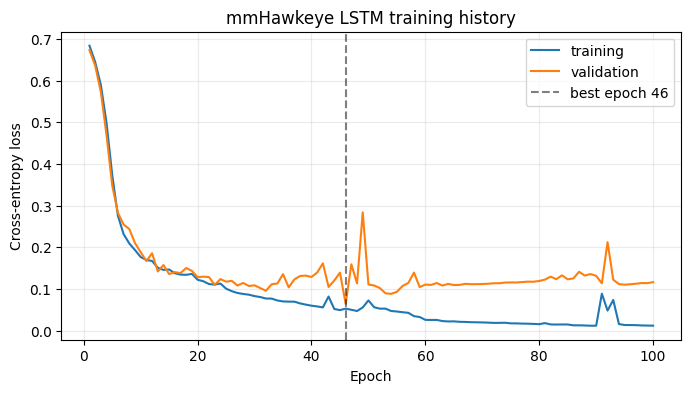

In [27]:
history, best_epoch, best_validation_loss = train_model(
    model,
    X,
    y,
    splits,
    device=DEVICE,
    epochs=EPOCHS,
)

epochs_axis = [int(row["epoch"]) for row in history]
plt.figure(figsize=(8, 4))
plt.plot(epochs_axis, [row["training_loss"] for row in history], label="training")
plt.plot(epochs_axis, [row["validation_loss"] for row in history], label="validation")
plt.axvline(best_epoch, color="black", linestyle="--", alpha=0.5, label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("mmHawkeye LSTM training history")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


## 5. Locked-test evaluation

The test partition is evaluated once after validation has selected the retained model state.

In [28]:
def predict_probabilities(
    model: nn.Module,
    values: np.ndarray,
    *,
    device: torch.device = DEVICE,
    batch_size: int = BATCH_SIZE,
) -> np.ndarray:
    model.eval()
    probabilities = []
    with torch.inference_mode():
        for start in range(0, len(values), batch_size):
            batch = torch.from_numpy(values[start:start + batch_size]).float().to(device)
            probabilities.append(torch.softmax(model(batch), dim=1).cpu().numpy())
    return np.concatenate(probabilities, axis=0)

def evaluate_locked_test(
    model: nn.Module,
    values: np.ndarray,
    labels: np.ndarray,
    test_indices: np.ndarray,
    *,
    device: torch.device = DEVICE,
) -> tuple[dict[str, Any], np.ndarray, np.ndarray]:
    truth = labels[test_indices]
    probabilities = predict_probabilities(model, values[test_indices], device=device)
    predictions = np.argmax(probabilities, axis=1)
    uav_probability = probabilities[:, LABEL_TO_INDEX["uav"]]
    metrics = {
        "samples": int(len(truth)),
        "accuracy": float(accuracy_score(truth, predictions)),
        "precision": float(precision_score(truth, predictions, pos_label=LABEL_TO_INDEX["uav"], zero_division=0)),
        "recall": float(recall_score(truth, predictions, pos_label=LABEL_TO_INDEX["uav"], zero_division=0)),
        "f1": float(f1_score(truth, predictions, pos_label=LABEL_TO_INDEX["uav"], zero_division=0)),
        "roc_auc": float(roc_auc_score(truth, uav_probability)),
    }
    return metrics, probabilities, predictions


{
  "samples": 58,
  "accuracy": 0.8620689655172413,
  "precision": 0.8,
  "recall": 0.9655172413793104,
  "f1": 0.875,
  "roc_auc": 0.9857312722948871
}


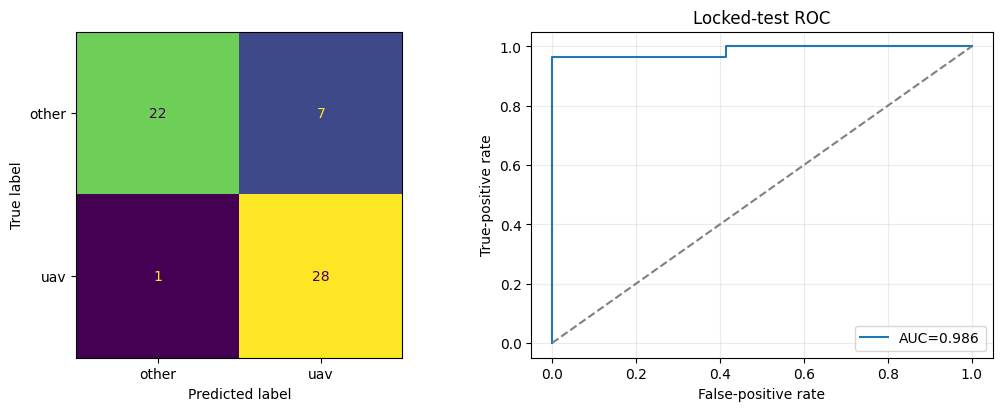

In [29]:
test_metrics, test_probabilities, test_predictions = evaluate_locked_test(
    model,
    X,
    y,
    splits["test"],
    device=DEVICE,
)
print(json.dumps(test_metrics, indent=2))

test_truth = y[splits["test"]]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ConfusionMatrixDisplay.from_predictions(
    test_truth,
    test_predictions,
    labels=[LABEL_TO_INDEX["other"], LABEL_TO_INDEX["uav"]],
    display_labels=["other", "uav"],
    colorbar=False,
    ax=axes[0],
)
false_positive_rate, true_positive_rate, _ = roc_curve(
    test_truth,
    test_probabilities[:, LABEL_TO_INDEX["uav"]],
)
axes[1].plot(false_positive_rate, true_positive_rate, label=f"AUC={test_metrics['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="Locked-test ROC")
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.show()


## 6. Export

This cell writes the validation-selected PyTorch state, an ONNX model with a dynamic batch dimension, and a manifest containing the complete preprocessing and dataset contract.

In [30]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
state_path = OUTPUT_DIR / "model_state.pt"
onnx_path = OUTPUT_DIR / "model.onnx"
manifest_path = OUTPUT_DIR / "manifest.json"

architecture = {
    "input_size": DOPPLER_BINS,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LSTM_LAYERS,
    "num_classes": len(LABEL_TO_INDEX),
}
split_segment_ids = {
    name: prepared["segment_ids"][indices].tolist()
    for name, indices in splits.items()
}
checkpoint = {
    "state_dict": {name: tensor.detach().cpu() for name, tensor in model.state_dict().items()},
    "architecture": architecture,
    "input_shape": [SEGMENT_FRAMES, DOPPLER_BINS],
    "axis_order": ["time", "centered_doppler_bin"],
    "label_to_index": LABEL_TO_INDEX,
    "normalization": normalization,
    "profile_fingerprint": dataset_audit["profile_fingerprint"],
    "feature_fingerprint": dataset_audit["feature_fingerprint"],
    "feature_version": dataset_audit["feature_version"],
    "seed": SEED,
    "best_epoch": best_epoch,
    "best_validation_loss": best_validation_loss,
    "test_metrics": test_metrics,
}
torch.save(checkpoint, state_path)

model_cpu = copy.deepcopy(model).cpu().eval()
example_input = torch.zeros(2, SEGMENT_FRAMES, DOPPLER_BINS, dtype=torch.float32)
torch.onnx.export(
    model_cpu,
    example_input,
    onnx_path,
    input_names=["doppler_time"],
    output_names=["logits"],
    dynamic_axes={"doppler_time": {0: "batch"}, "logits": {0: "batch"}},
    opset_version=ONNX_OPSET,
)
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)
reference = ReferenceEvaluator(onnx_model)
parity_input = np.random.default_rng(SEED).normal(size=(3, SEGMENT_FRAMES, DOPPLER_BINS)).astype(np.float32)
with torch.inference_mode():
    torch_logits = model_cpu(torch.from_numpy(parity_input)).numpy()
onnx_logits = reference.run(None, {"doppler_time": parity_input})[0]
maximum_parity_error = float(np.max(np.abs(torch_logits - onnx_logits)))
if maximum_parity_error > 1e-4:
    raise RuntimeError(f"PyTorch/ONNX parity error is too large: {maximum_parity_error}")

artifacts = {"pytorch": state_path.name, "onnx": onnx_path.name}
onnx_data_path = onnx_path.with_name(onnx_path.name + ".data")
if onnx_data_path.is_file():
    artifacts["onnx_data"] = onnx_data_path.name

manifest = {
    "model": "mmHawkeye paper-inspired two-layer LSTM",
    "paper_classifier_reproduction": False,
    "artifacts": artifacts,
    "label_to_index": LABEL_TO_INDEX,
    "input_contract": {
        "dtype": "float32",
        "shape": ["batch", SEGMENT_FRAMES, DOPPLER_BINS],
        "axis_order": ["batch", "time", "centered_doppler_bin"],
        "duration_seconds": 3.6,
        "representation": "training-standardized aligned log1p linear amplitude",
        "dc_removal": "paper center-bin baseline from off-center body-peak frames; zero floor",
        "alignment": "pre-removal body peak centered; one-bin tolerance; linear interpolation; zero fill",
    },
    "architecture": architecture,
    "training": {
        "optimizer": "Adam",
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "loss": "cross_entropy",
        "seed": SEED,
        "best_epoch": best_epoch,
        "best_validation_loss": best_validation_loss,
    },
    "split_policy": {
        "kind": "seeded stratified segment-level",
        "requested_fractions": {"train": 0.70, "validation": 0.15, "test": 0.15},
        "resolved": dataset_audit["split_summary"],
        "segment_ids": split_segment_ids,
    },
    "normalization": normalization,
    "dataset": dataset_audit,
    "test_metrics": test_metrics,
    "onnx": {"opset": ONNX_OPSET, "maximum_parity_error": maximum_parity_error},
    "software": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pytorch": torch.__version__,
        "onnx": onnx.__version__,
        "scikit_learn": sklearn.__version__,
    },
    "limitations": [
        "The paper does not disclose its exact tensor dimensions; this model uses the repository-native 36x64 contract.",
        "The split is segment-level, so segments from one capture may occur in different partitions.",
        "The model is valid only for the recorded feature and profile fingerprints.",
    ],
}
manifest_path.write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")
print("Saved:", state_path)
print("Saved:", onnx_path)
print("Saved:", manifest_path)
print("maximum PyTorch/ONNX parity error:", maximum_parity_error)


/tmp/ipykernel_539/4098894825.py:35: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `MmHawkeyeLSTM([...]` with `torch.export.export(..., strict=False)`...


/usr/lib/python3.12/contextlib.py:144: UserWarning: The tensor attributes self.lstm._flat_weights[0], self.lstm._flat_weights[1], self.lstm._flat_weights[2], self.lstm._flat_weights[3], self.lstm._flat_weights[4], self.lstm._flat_weights[5], self.lstm._flat_weights[6], self.lstm._flat_weights[7] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `MmHawkeyeLSTM([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Saved: /content/drive/MyDrive/UREX/Radar-UREx/training_output/mmhawkeye_lstm/model_state.pt
Saved: /content/drive/MyDrive/UREX/Radar-UREx/training_output/mmhawkeye_lstm/model.onnx
Saved: /content/drive/MyDrive/UREX/Radar-UREx/training_output/mmhawkeye_lstm/manifest.json
maximum PyTorch/ONNX parity error: 2.384185791015625e-07
